In [8]:
import mne
import pandas as pd

In [11]:
raw = mne.io.read_raw_fif("/Users/maryamvalian/Data/ds005810/sub-01/ses-ImageNet01/meg/sub-01_ses-ImageNet01_task-ImageNet_run-01_meg.fif", preload=False)
#raw.info["bads"]  
raw

Opening raw data file /Users/maryamvalian/Data/ds005810/sub-01/ses-ImageNet01/meg/sub-01_ses-ImageNet01_task-ImageNet_run-01_meg.fif...
    Read 5 compensation matrices
    Range : 0 ... 383999 =      0.000 ...   319.999 secs
Ready.
Current compensation grade : 3


<Raw | sub-01_ses-ImageNet01_task-ImageNet_run-01_meg.fif, 409 x 384000 (320.0 s), ~563 KiB, data not loaded>

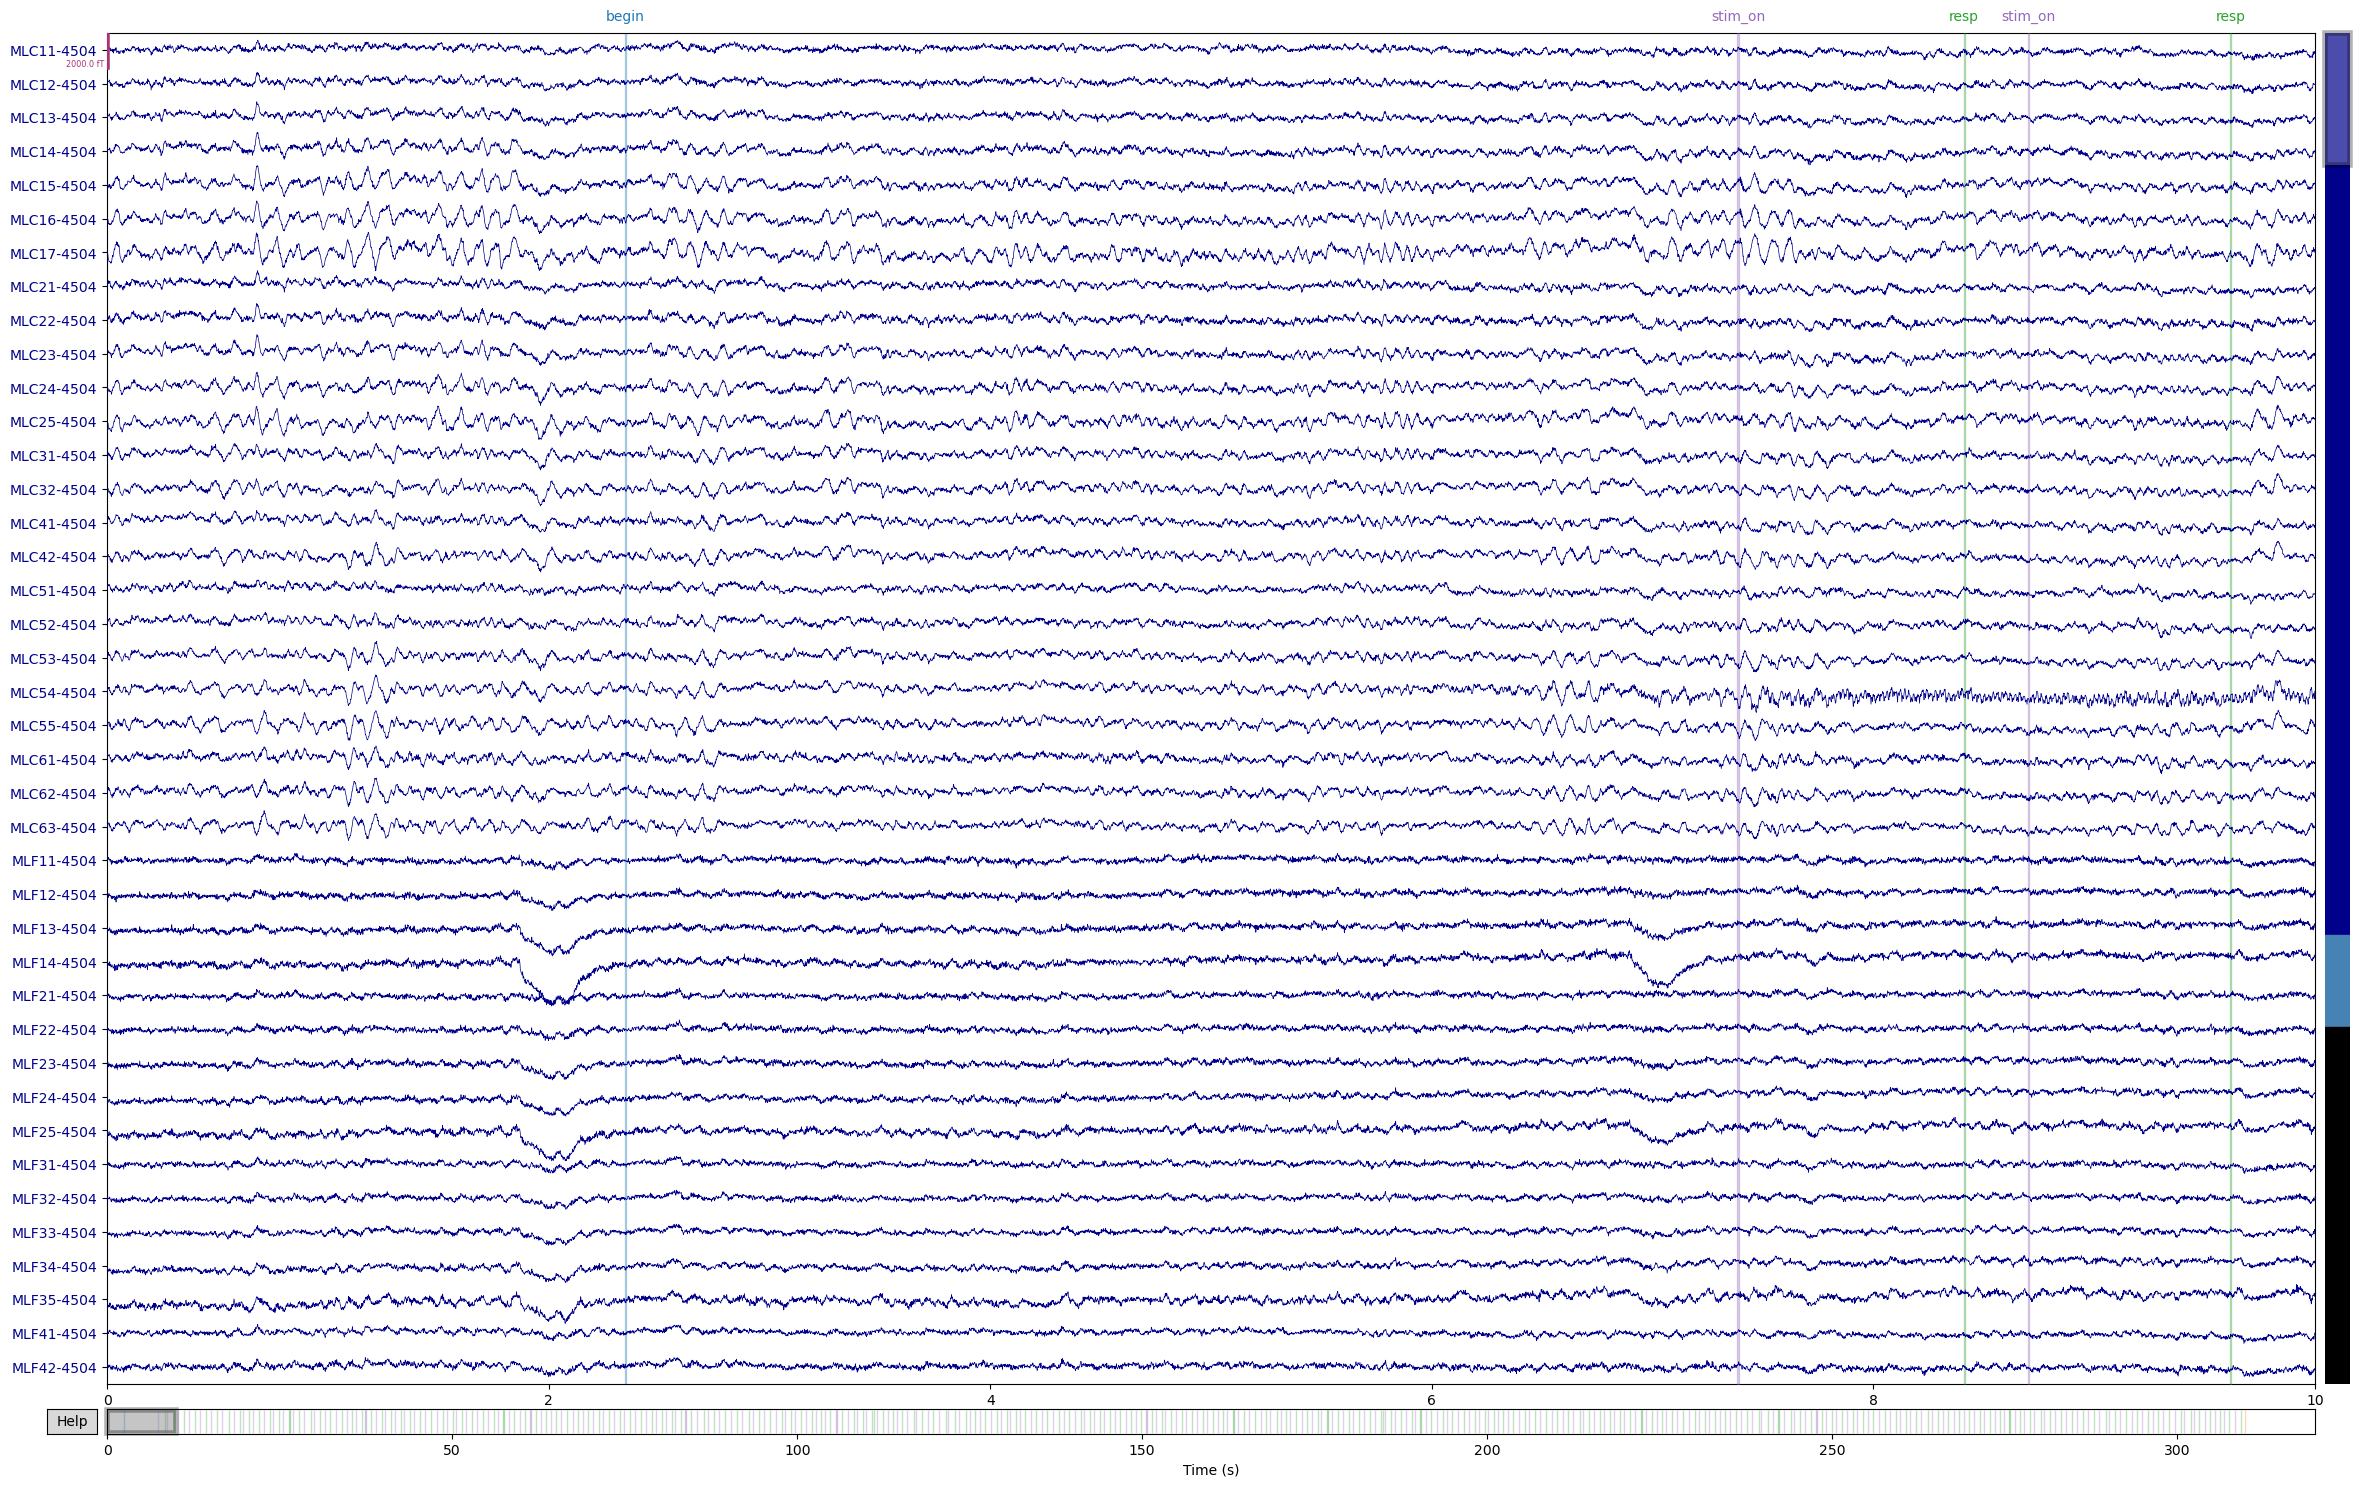

In [6]:
p=raw.plot(n_channels=40, duration=10)

404 events found on stim channel UPPT001
Event IDs: [1 2 4 8]
Not setting metadata
404 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Removing 5 compensators from info because not all compensation channels were picked.
Removing 5 compensators from info because not all compensation channels were picked.
Removing 5 compensators from info because not all compensation channels were picked.


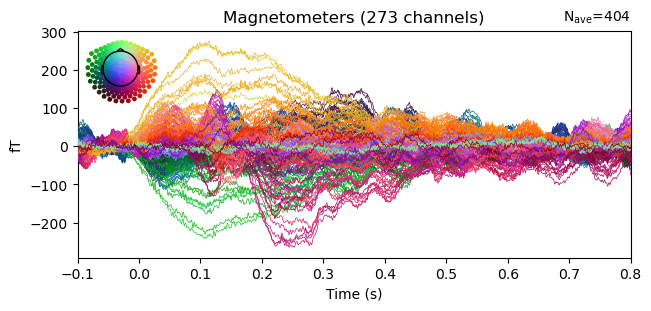

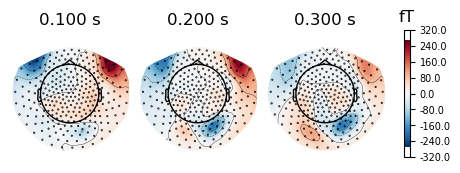

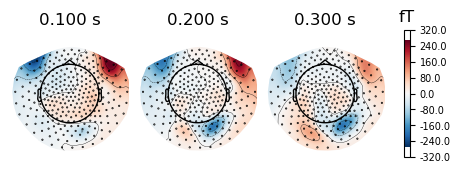

In [12]:
events = mne.find_events(raw, stim_channel="UPPT001")
epochs = mne.Epochs(raw, events, tmin=-0.1, tmax=0.8, baseline=(-0.1, 0))
#epochs[:5].plot()
evoked = epochs.average()


p=evoked.plot()


evoked.plot_topomap(times=[0.1, 0.2, 0.3], ch_type="mag")

In [13]:
meta = pd.read_csv("/Users/maryamvalian/Data/ds005810/derivatives/detailed_events/sub-01_events.csv")
meta.head()

,event_name,task,subject,session,run,image_id,class_id,class,super_class,stim_is_animate,resp_is_animate,resp_is_right,RT
0,stim_on,ImageNet,1,ImageNet01,1,n03871628_5258,n03871628,packet,container,False,False,True,1.094761
1,stim_on,ImageNet,1,ImageNet01,1,n01737021_871,n01737021,water snake,reptile,True,True,True,0.971282
2,stim_on,ImageNet,1,ImageNet01,1,n02364673_2164,n02364673,guinea pig,mammal,True,True,True,0.957222
3,stim_on,ImageNet,1,ImageNet01,1,n04162706_15953,n04162706,seat belt,covering,False,True,False,0.933252
4,stim_on,ImageNet,1,ImageNet01,1,n03983396_2114,n03983396,pop bottle,container,False,False,True,0.955911
